# Análisis de Opciones: Simulación, Sensibilidad y Visualización

Sofia Anaya Palafox

738594

Ingeniería Financiera


## Parte 1: Simulación de Opciones Call y Put y Comparación con Black-Scholes


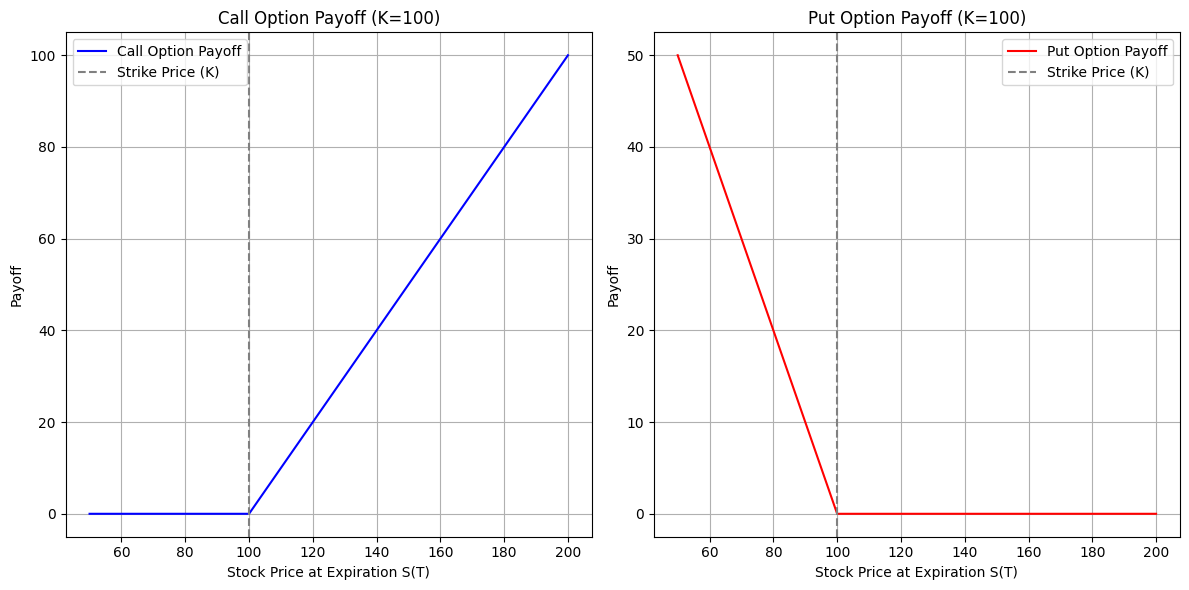

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Strike price (precio de ejercicio)
k = 100

# Simular S(T) entre [50 y 200]
s_t = np.linspace(50, 200, 100) #inicio, fin, la cantidad de números a generar

# Calcular call option: max(S(T) - K, 0)
call_payoff = np.maximum(s_t - k, 0)

# Calcular put option payoff: max(K - S(T), 0)
put_payoff = np.maximum(k - s_t, 0)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(s_t, call_payoff, label='Call Option Payoff', color='blue')
plt.axvline(k, color='gray', linestyle='--', label='Strike Price (K)')
plt.title('Call Option Payoff (K=100)')
plt.xlabel('Stock Price at Expiration S(T)')
plt.ylabel('Payoff')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(s_t, put_payoff, label='Put Option Payoff', color='red')
plt.axvline(k, color='gray', linestyle='--', label='Strike Price (K)')
plt.title('Put Option Payoff (K=100)')
plt.xlabel('Stock Price at Expiration S(T)')
plt.ylabel('Payoff')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Simulación de S(T) y Distribución de Payoffs

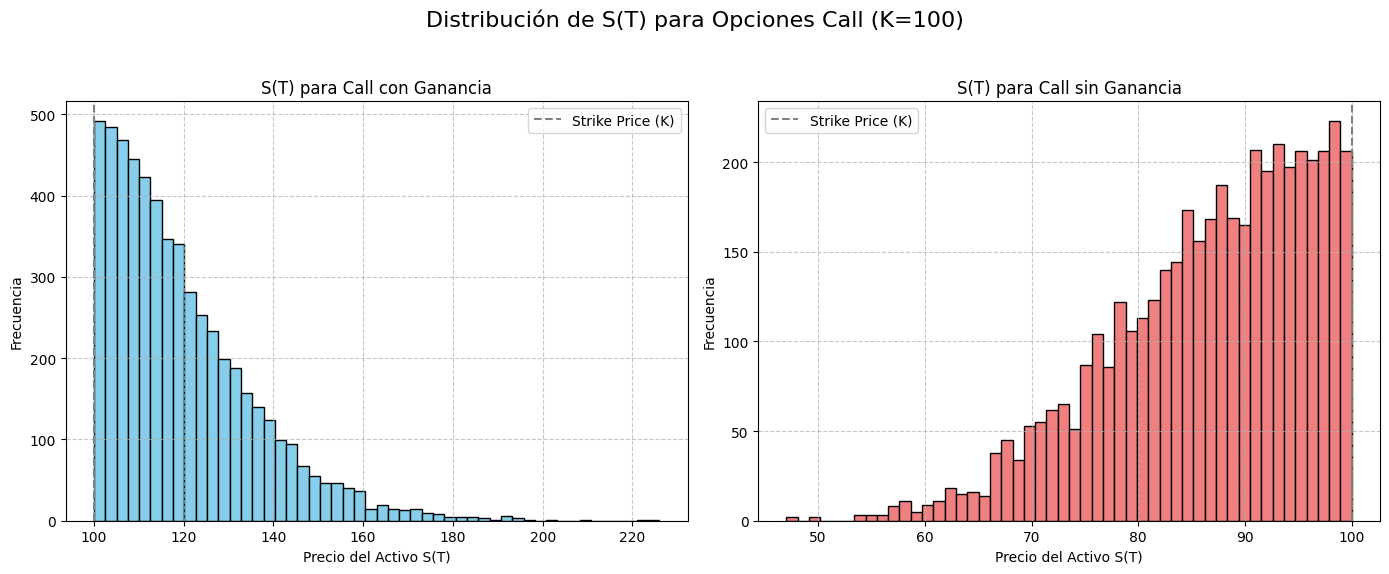

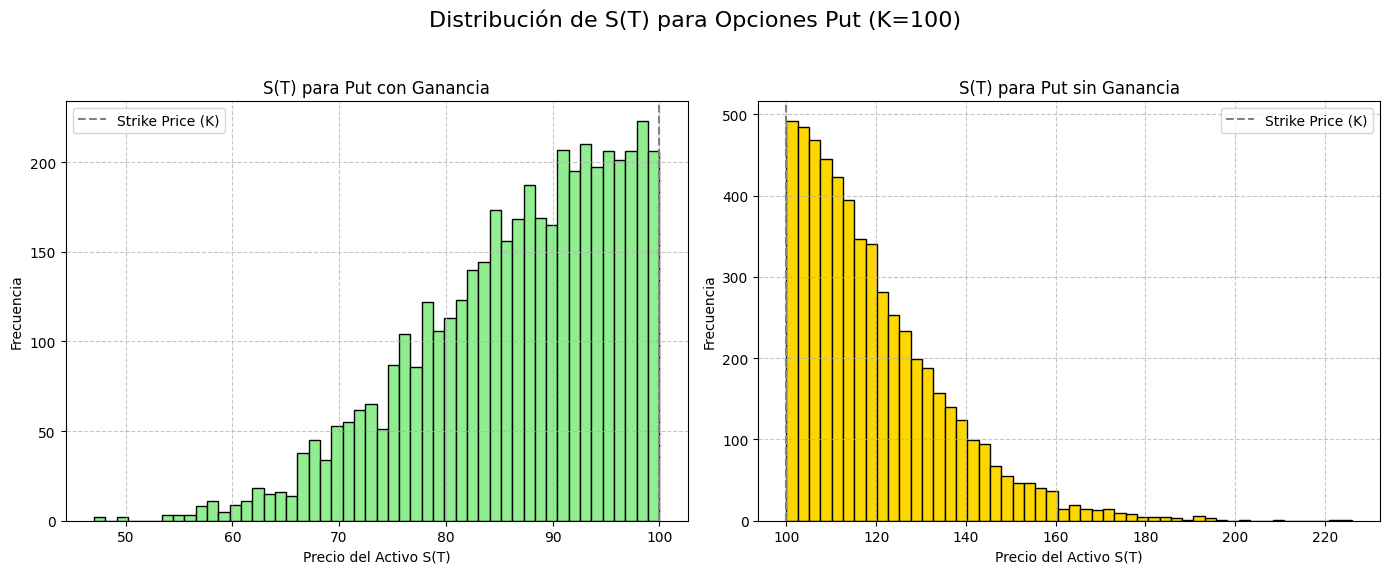

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
S0 = 100    # Precio inicial del activo subyacente
K = 100     # Precio de ejercicio (strike price)
r = 0.05    # Tasa de interés libre de riesgo (5%)
vol = 0.20  # Volatilidad (20%)
T = 1       # Tiempo hasta el vencimiento (1 año)
num_simulations = 10000 # Número de precios S(T) a simular

# Simulación de S(T) usando el modelo de Movimiento Browniano Geométrico
# Generar números aleatorios de una distribución normal estándar
np.random.seed(42)
Z = np.random.standard_normal(num_simulations)

# Calcular S(T) para cada simulación
S_T_simulated = S0 * np.exp((r - 0.5 * vol**2) * T + vol * np.sqrt(T) * Z)

# Calcular las ganancias (payoffs) para las opciones Call y Put
# Ganacia = payoff - prima
call_payoffs_sim = np.maximum(S_T_simulated - K, 0)
put_payoffs_sim = np.maximum(K - S_T_simulated, 0)

# HISTOGRAMAS

# S(T) que si resultaron en ganancia para la opción Call
s_t_call_gain = S_T_simulated[call_payoffs_sim > 0]
# S(T) que no resultaron en ganancia (payoff = 0) para la opción Call
s_t_call_no_gain = S_T_simulated[call_payoffs_sim == 0]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(s_t_call_gain, bins=50, color='skyblue', edgecolor='black')
plt.axvline(K, color='gray', linestyle='--', label='Strike Price (K)')
plt.title('S(T) para Call con Ganancia')
plt.xlabel('Precio del Activo S(T)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.hist(s_t_call_no_gain, bins=50, color='lightcoral', edgecolor='black')
plt.axvline(K, color='gray', linestyle='--', label='Strike Price (K)')
plt.title('S(T) para Call sin Ganancia')
plt.xlabel('Precio del Activo S(T)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Distribución de S(T) para Opciones Call (K=100)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para el suptitle
plt.show()

# S(T) que resultaron en ganancia para la opción Put
s_t_put_gain = S_T_simulated[put_payoffs_sim > 0]
# S(T) que resultaron en no ganancia (payoff = 0) para la opción Put
s_t_put_no_gain = S_T_simulated[put_payoffs_sim == 0]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(s_t_put_gain, bins=50, color='lightgreen', edgecolor='black')
plt.axvline(K, color='gray', linestyle='--', label='Strike Price (K)')
plt.title('S(T) para Put con Ganancia')
plt.xlabel('Precio del Activo S(T)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.hist(s_t_put_no_gain, bins=50, color='gold', edgecolor='black')
plt.axvline(K, color='gray', linestyle='--', label='Strike Price (K)')
plt.title('S(T) para Put sin Ganancia')
plt.xlabel('Precio del Activo S(T)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Distribución de S(T) para Opciones Put (K=100)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Máxima Ganancia y Payoff Promedio Total de las Simulaciones

In [18]:
# Máxima ganancia observada para la opción Call
max_call_gain_overall = np.max(call_payoffs_sim)

# Payoff promedio de la opción Call (incluyendo ceros)
average_call_payoff_overall = np.mean(call_payoffs_sim)

# Máxima ganancia observada para la opción Put
max_put_gain_overall = np.max(put_payoffs_sim)

# Payoff promedio de la opción Put (incluyendo ceros)
average_put_payoff_overall = np.mean(put_payoffs_sim)

print(f"--- Resumen General de Payoffs (K={K}) ---")
print("\n")

print(f"**Opción Call:**")
print(f"  Ganancia máxima observada: {max_call_gain_overall:.2f}")
print(f"  Payoff promedio (esperado) total: {average_call_payoff_overall:.2f}")
print("\n")

print(f"**Opción Put:**")
print(f"  Ganancia máxima observada: {max_put_gain_overall:.2f}")
print(f"  Payoff promedio (esperado) total: {average_put_payoff_overall:.2f}")
print("\n")


--- Resumen General de Payoffs (K=100) ---


**Opción Call:**
  Ganancia máxima observada: 125.97
  Payoff promedio (esperado) total: 10.99


**Opción Put:**
  Ganancia máxima observada: 52.97
  Payoff promedio (esperado) total: 5.89




### Fórmula de Black-Scholes para Opciones Call y Put


In [19]:
import numpy as np
from scipy.stats import norm

def black_scholes(S, K, T, r, vol, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * vol**2) * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option_type debe ser 'call' o 'put'")
    return price

# Parámetros iniciales de la simulación
S0_bs = 100
K_bs = 100
T_bs = 1
r_bs = 0.05
vol_bs = 0.20

# Calcular precios Black-Scholes
call_price_bs = black_scholes(S0_bs, K_bs, T_bs, r_bs, vol_bs, option_type='call')
put_price_bs = black_scholes(S0_bs, K_bs, T_bs, r_bs, vol_bs, option_type='put')

print(f"--- Precios Teóricos Black-Scholes (S0={S0_bs}, K={K_bs}, T={T_bs} año, r={r_bs*100:.0f}%, Vol={vol_bs*100:.0f}%) ---")
print(f"  Precio Opción Call (Black-Scholes): {call_price_bs:.2f}")
print(f"  Precio Opción Put (Black-Scholes): {put_price_bs:.2f}")

--- Precios Teóricos Black-Scholes (S0=100, K=100, T=1 año, r=5%, Vol=20%) ---
  Precio Opción Call (Black-Scholes): 10.45
  Precio Opción Put (Black-Scholes): 5.57


### Comparación de Payoffs Simulados con Precios Black-Scholes



In [20]:
# Los valores average_call_payoff_overall y average_put_payoff_overall ya fueron calculados en la celda anterior.

print(f"--- Comparación (K={K_bs}) ---")
print("\n")

print(f"**Opción Call:**")
print(f"  Payoff promedio simulado: {average_call_payoff_overall:.2f}")
print(f"  Precio Black-Scholes: {call_price_bs:.2f}")
print(f"  Diferencia: {abs(average_call_payoff_overall - call_price_bs):.2f}")
print("\n")

print(f"**Opción Put:**")
print(f"  Payoff promedio simulado: {average_put_payoff_overall:.2f}")
print(f"  Precio Black-Scholes: {put_price_bs:.2f}")
print(f"  Diferencia: {abs(average_put_payoff_overall - put_price_bs):.2f}")
print("\n")

print("Nota: Las diferencias se deben a que el payoff promedio de la simulación no es el precio de la opción, sino la esperanza del payoff, que es un estimador del precio de la opción. La fórmula de Black-Scholes da el precio teórico en un modelo idealizado.")


--- Comparación (K=100) ---


**Opción Call:**
  Payoff promedio simulado: 10.99
  Precio Black-Scholes: 10.45
  Diferencia: 0.54


**Opción Put:**
  Payoff promedio simulado: 5.89
  Precio Black-Scholes: 5.57
  Diferencia: 0.32


Nota: Las diferencias se deben a que el payoff promedio de la simulación no es el precio de la opción, sino la esperanza del payoff, que es un estimador del precio de la opción. La fórmula de Black-Scholes da el precio teórico en un modelo idealizado.


## Simulación con Múltiples Volatilidades

In [32]:
import numpy as np

# Parámetros fijos de la simulación
S0 = 100    # Precio inicial del activo subyacente
K = 100     # Precio de ejercicio (strike price)
r = 0.05    # Tasa de interés libre de riesgo (5%)
vol = 0.20  # Volatilidad (20%)
num_simulations = 10000 # Número de precios S(T) a simular

# Tiempos hasta el vencimiento a probar
times_to_expiration = [0.25, 0.5, 1, 2] # 3 meses, 6 meses, 1 año, 2 años

print(f"--- Resumen de Payoffs para Diferentes Tiempos al Vencimiento (K={K}, r={r*100:.0f}%, Vol={vol*100:.0f}%) ---")

for current_T in times_to_expiration:
    print(f"\n=== Tiempo al Vencimiento (T): {current_T} año(s) ===")

    # Simulación de S(T) para el tiempo al vencimiento actual
    np.random.seed(42) # Usar la misma semilla para comparabilidad si se desea
    Z = np.random.standard_normal(num_simulations)
    S_T_simulated = S0 * np.exp((r - 0.5 * vol**2) * current_T + vol * np.sqrt(current_T) * Z)

    # Calcular las ganancias (payoffs) para las opciones Call y Put
    call_payoffs_sim = np.maximum(S_T_simulated - K, 0)
    put_payoffs_sim = np.maximum(K - S_T_simulated, 0)

    # -- Opción Call --
    max_call_gain_overall = np.max(call_payoffs_sim)
    average_call_payoff_overall = np.mean(call_payoffs_sim)

    print(f"  **Opción Call:**")
    print(f"    Ganancia máxima observada: {max_call_gain_overall:.2f}")
    print(f"    Payoff promedio (esperado) total: {average_call_payoff_overall:.2f}")

    # -- Opción Put --
    max_put_gain_overall = np.max(put_payoffs_sim)
    average_put_payoff_overall = np.mean(put_payoffs_sim)

    print(f"  **Opción Put:**")
    print(f"    Ganancia máxima observada: {max_put_gain_overall:.2f}")
    print(f"    Payoff promedio (esperado) total: {average_put_payoff_overall:.2f}")



--- Resumen de Payoffs para Diferentes Tiempos al Vencimiento (K=100, r=5%, Vol=20%) ---

=== Tiempo al Vencimiento (T): 0.25 año(s) ===
  **Opción Call:**
    Ganancia máxima observada: 49.20
    Payoff promedio (esperado) total: 4.67
  **Opción Put:**
    Ganancia máxima observada: 31.94
    Payoff promedio (esperado) total: 3.43

=== Tiempo al Vencimiento (T): 0.5 año(s) ===
  **Opción Call:**
    Ganancia máxima observada: 76.87
    Payoff promedio (esperado) total: 7.06
  **Opción Put:**
    Ganancia máxima observada: 41.71
    Payoff promedio (esperado) total: 4.55

=== Tiempo al Vencimiento (T): 1 año(s) ===
  **Opción Call:**
    Ganancia máxima observada: 125.97
    Payoff promedio (esperado) total: 10.99
  **Opción Put:**
    Ganancia máxima observada: 52.97
    Payoff promedio (esperado) total: 5.89

=== Tiempo al Vencimiento (T): 2 año(s) ===
  **Opción Call:**
    Ganancia máxima observada: 222.36
    Payoff promedio (esperado) total: 17.82
  **Opción Put:**
    Ganancia m

## Parte 2: Análisis de Sensibilidad (Griegas)



### Sensibilidad por Tiempo al Vencimiento (T)



## Simulación con Múltiples Precios de Ejercicio (K)

In [31]:
import numpy as np

# Parámetros fijos de la simulación
S0 = 100    # Precio inicial del activo subyacente
r = 0.05    # Tasa de interés libre de riesgo (5%)
vol = 0.20  # Volatilidad (20%)
T = 1       # Tiempo hasta el vencimiento (1 año)
num_simulations = 10000 # Número de precios S(T) a simular

# Precios de ejercicio a probar
strike_prices = [80, 90, 100, 110, 120]

print(f"--- Resumen de Payoffs para Diferentes Precios de Ejercicio (S0={S0}, r={r*100:.0f}%, Vol={vol*100:.0f}%, T={T} año) ---")

for current_K in strike_prices:
    print(f"\n=== Precio de Ejercicio (K): {current_K} ===")

    # Simulación de S(T) (se mantiene igual ya que S0, r, vol, T son fijos)
    np.random.seed(42) # Usar la misma semilla para comparabilidad si se desea
    Z = np.random.standard_normal(num_simulations)
    S_T_simulated = S0 * np.exp((r - 0.5 * vol**2) * T + vol * np.sqrt(T) * Z)

    # Calcular las ganancias (payoffs) para las opciones Call y Put con el K actual
    call_payoffs_sim = np.maximum(S_T_simulated - current_K, 0)
    put_payoffs_sim = np.maximum(current_K - S_T_simulated, 0)

    # -- Opción Call --
    max_call_gain_overall = np.max(call_payoffs_sim)
    average_call_payoff_overall = np.mean(call_payoffs_sim)

    print(f"  **Opción Call:**")
    print(f"    Ganancia máxima observada: {max_call_gain_overall:.2f}")
    print(f"    Payoff promedio (esperado) total: {average_call_payoff_overall:.2f}")

    # -- Opción Put --
    max_put_gain_overall = np.max(put_payoffs_sim)
    average_put_payoff_overall = np.mean(put_payoffs_sim)

    print(f"  **Opción Put:**")
    print(f"    Ganancia máxima observada: {max_put_gain_overall:.2f}")
    print(f"    Payoff promedio (esperado) total: {average_put_payoff_overall:.2f}")


--- Resumen de Payoffs para Diferentes Precios de Ejercicio (S0=100, r=5%, Vol=20%, T=1 año) ---

=== Precio de Ejercicio (K): 80 ===
  **Opción Call:**
    Ganancia máxima observada: 145.97
    Payoff promedio (esperado) total: 25.83
  **Opción Put:**
    Ganancia máxima observada: 32.97
    Payoff promedio (esperado) total: 0.74

=== Precio de Ejercicio (K): 90 ===
  **Opción Call:**
    Ganancia máxima observada: 135.97
    Payoff promedio (esperado) total: 17.55
  **Opción Put:**
    Ganancia máxima observada: 42.97
    Payoff promedio (esperado) total: 2.45

=== Precio de Ejercicio (K): 100 ===
  **Opción Call:**
    Ganancia máxima observada: 125.97
    Payoff promedio (esperado) total: 10.99
  **Opción Put:**
    Ganancia máxima observada: 52.97
    Payoff promedio (esperado) total: 5.89

=== Precio de Ejercicio (K): 110 ===
  **Opción Call:**
    Ganancia máxima observada: 115.97
    Payoff promedio (esperado) total: 6.35
  **Opción Put:**
    Ganancia máxima observada: 62.97
 

### Sensibilidad por Tasa de Interés Libre de Riesgo (r)



In [23]:
# Parámetros fijos de la simulación para la sensibilidad de 'r'
S0_r = 100
K_r = 100
T_r = 1
vol_r = 0.20

# Tasas de interés a probar
rates = [0.05, 0.10, 0.15, 0.20] # 5%, 10%, 15%, 20%

print(f"--- Resumen de Precios Black-Scholes para Diferentes Tasas de Interés (S0={S0_r}, K={K_r}, T={T_r} año, Vol={vol_r*100:.0f}%) ---")

for current_r in rates:
    print(f"\n=== Tasa de Interés (r): {current_r*100:.0f}% ===")

    # Calcular precios Black-Scholes para el 'r' actual
    call_price_bs_r = black_scholes(S0_r, K_r, T_r, current_r, vol_r, option_type='call')
    put_price_bs_r = black_scholes(S0_r, K_r, T_r, current_r, vol_r, option_type='put')

    print(f"  **Opción Call (BS):** {call_price_bs_r:.2f}")
    print(f"  **Opción Put (BS):** {put_price_bs_r:.2f}")

--- Resumen de Precios Black-Scholes para Diferentes Tasas de Interés (S0=100, K=100, T=1 año, Vol=20%) ---

=== Tasa de Interés (r): 5% ===
  **Opción Call (BS):** 10.45
  **Opción Put (BS):** 5.57

=== Tasa de Interés (r): 10% ===
  **Opción Call (BS):** 13.27
  **Opción Put (BS):** 3.75

=== Tasa de Interés (r): 15% ===
  **Opción Call (BS):** 16.36
  **Opción Put (BS):** 2.43

=== Tasa de Interés (r): 20% ===
  **Opción Call (BS):** 19.63
  **Opción Put (BS):** 1.50


### Sensibilidad por Precio del Activo Subyacente (S0)



In [24]:
# Parámetros fijos para la sensibilidad de 'S0'
K_s0 = 100
T_s0 = 1
r_s0 = 0.05
vol_s0 = 0.20

# Precios del activo subyacente a probar
asset_prices = [80, 90, 100, 110, 120]

print(f"--- Resumen de Precios Black-Scholes para Diferentes Precios del Activo Subyacente (K={K_s0}, T={T_s0} año, r={r_s0*100:.0f}%, Vol={vol_s0*100:.0f}%) ---")

for current_S0 in asset_prices:
    print(f"\n=== Precio del Activo (S0): {current_S0} ===")

    # Calcular precios Black-Scholes para el 'S0' actual
    call_price_bs_s0 = black_scholes(current_S0, K_s0, T_s0, r_s0, vol_s0, option_type='call')
    put_price_bs_s0 = black_scholes(current_S0, K_s0, T_s0, r_s0, vol_s0, option_type='put')

    print(f"  **Opción Call (BS):** {call_price_bs_s0:.2f}")
    print(f"  **Opción Put (BS):** {put_price_bs_s0:.2f}")


--- Resumen de Precios Black-Scholes para Diferentes Precios del Activo Subyacente (K=100, T=1 año, r=5%, Vol=20%) ---

=== Precio del Activo (S0): 80 ===
  **Opción Call (BS):** 1.86
  **Opción Put (BS):** 16.98

=== Precio del Activo (S0): 90 ===
  **Opción Call (BS):** 5.09
  **Opción Put (BS):** 10.21

=== Precio del Activo (S0): 100 ===
  **Opción Call (BS):** 10.45
  **Opción Put (BS):** 5.57

=== Precio del Activo (S0): 110 ===
  **Opción Call (BS):** 17.66
  **Opción Put (BS):** 2.79

=== Precio del Activo (S0): 120 ===
  **Opción Call (BS):** 26.17
  **Opción Put (BS):** 1.29


### Sensibilidad por Volatilidad (sigma)



In [25]:
# Parámetros fijos para la sensibilidad de 'vol'
S0_vol = 100
K_vol = 100
T_vol = 1
r_vol = 0.05

# Volatilidades a probar
volatilities = [0.10, 0.20, 0.30, 0.40, 0.50] # 10%, 20%, 30%, 40%, 50%

print(f"--- Resumen de Precios Black-Scholes para Diferentes Volatilidades (S0={S0_vol}, K={K_vol}, T={T_vol} año, r={r_vol*100:.0f}%) ---")

for current_vol in volatilities:
    print(f"\n=== Volatilidad (sigma): {current_vol*100:.0f}% ===")

    # Calcular precios Black-Scholes para la 'vol' actual
    call_price_bs_vol = black_scholes(S0_vol, K_vol, T_vol, r_vol, current_vol, option_type='call')
    put_price_bs_vol = black_scholes(S0_vol, K_vol, T_vol, r_vol, current_vol, option_type='put')

    print(f"  **Opción Call (BS):** {call_price_bs_vol:.2f}")
    print(f"  **Opción Put (BS):** {put_price_bs_vol:.2f}")


--- Resumen de Precios Black-Scholes para Diferentes Volatilidades (S0=100, K=100, T=1 año, r=5%) ---

=== Volatilidad (sigma): 10% ===
  **Opción Call (BS):** 6.80
  **Opción Put (BS):** 1.93

=== Volatilidad (sigma): 20% ===
  **Opción Call (BS):** 10.45
  **Opción Put (BS):** 5.57

=== Volatilidad (sigma): 30% ===
  **Opción Call (BS):** 14.23
  **Opción Put (BS):** 9.35

=== Volatilidad (sigma): 40% ===
  **Opción Call (BS):** 18.02
  **Opción Put (BS):** 13.15

=== Volatilidad (sigma): 50% ===
  **Opción Call (BS):** 21.79
  **Opción Put (BS):** 16.92


## Parte 3: Visualización de la Sensibilidad



### Gráfica de Precio de la Opción vs Precio del Activo Subyacente (S0)

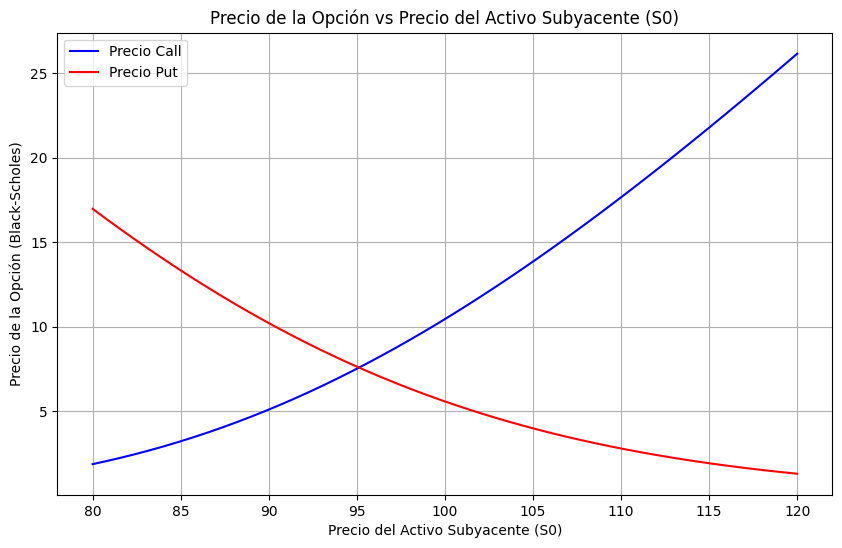

In [26]:
import matplotlib.pyplot as plt

# Parámetros fijos para la sensibilidad de 'S0'
K_plot_s0 = 100
T_plot_s0 = 1
r_plot_s0 = 0.05
vol_plot_s0 = 0.20

# Precios del activo subyacente a probar (rango más fino para la gráfica)
asset_prices_range = np.linspace(80, 120, 50)

call_prices_s0 = [black_scholes(s, K_plot_s0, T_plot_s0, r_plot_s0, vol_plot_s0, option_type='call') for s in asset_prices_range]
put_prices_s0 = [black_scholes(s, K_plot_s0, T_plot_s0, r_plot_s0, vol_plot_s0, option_type='put') for s in asset_prices_range]

plt.figure(figsize=(10, 6))
plt.plot(asset_prices_range, call_prices_s0, label='Precio Call', color='blue')
plt.plot(asset_prices_range, put_prices_s0, label='Precio Put', color='red')
plt.xlabel('Precio del Activo Subyacente (S0)')
plt.ylabel('Precio de la Opción (Black-Scholes)')
plt.title('Precio de la Opción vs Precio del Activo Subyacente (S0)')
plt.grid(True)
plt.legend()
plt.show()

### Gráfica de Precio de la Opción vs Precio de Ejercicio (K)

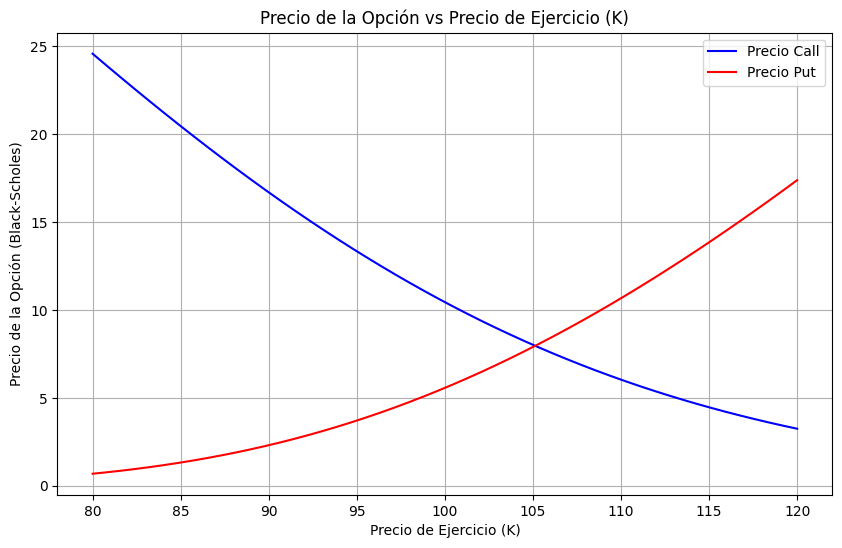

In [27]:
# Parámetros fijos para la sensibilidad de 'K'
S0_plot_k = 100
T_plot_k = 1
r_plot_k = 0.05
vol_plot_k = 0.20

# Precios de ejercicio a probar (rango más fino para la gráfica)
strike_prices_range = np.linspace(80, 120, 50)

call_prices_k = [black_scholes(S0_plot_k, k, T_plot_k, r_plot_k, vol_plot_k, option_type='call') for k in strike_prices_range]
put_prices_k = [black_scholes(S0_plot_k, k, T_plot_k, r_plot_k, vol_plot_k, option_type='put') for k in strike_prices_range]

plt.figure(figsize=(10, 6))
plt.plot(strike_prices_range, call_prices_k, label='Precio Call', color='blue')
plt.plot(strike_prices_range, put_prices_k, label='Precio Put', color='red')
plt.xlabel('Precio de Ejercicio (K)')
plt.ylabel('Precio de la Opción (Black-Scholes)')
plt.title('Precio de la Opción vs Precio de Ejercicio (K)')
plt.grid(True)
plt.legend()
plt.show()

### Gráfica de Precio de la Opción vs Volatilidad (sigma)

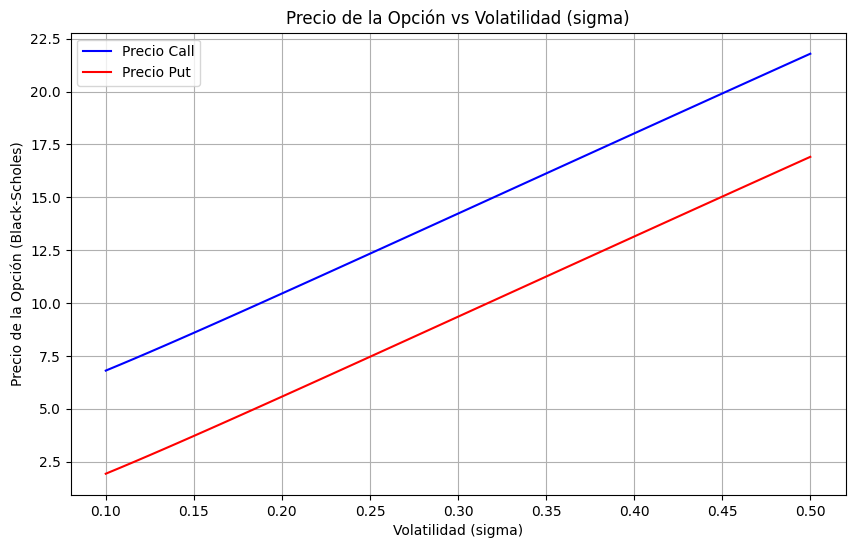

In [28]:
# Parámetros fijos para la sensibilidad de 'vol'
S0_plot_vol = 100
K_plot_vol = 100
T_plot_vol = 1
r_plot_vol = 0.05

# Volatilidades a probar (rango más fino para la gráfica)
volatilities_range = np.linspace(0.10, 0.50, 50)

call_prices_vol = [black_scholes(S0_plot_vol, K_plot_vol, T_plot_vol, r_plot_vol, vol, option_type='call') for vol in volatilities_range]
put_prices_vol = [black_scholes(S0_plot_vol, K_plot_vol, T_plot_vol, r_plot_vol, vol, option_type='put') for vol in volatilities_range]

plt.figure(figsize=(10, 6))
plt.plot(volatilities_range, call_prices_vol, label='Precio Call', color='blue')
plt.plot(volatilities_range, put_prices_vol, label='Precio Put', color='red')
plt.xlabel('Volatilidad (sigma)')
plt.ylabel('Precio de la Opción (Black-Scholes)')
plt.title('Precio de la Opción vs Volatilidad (sigma)')
plt.grid(True)
plt.legend()
plt.show()

### Gráfica de Precio de la Opción vs Tiempo al Vencimiento (T)

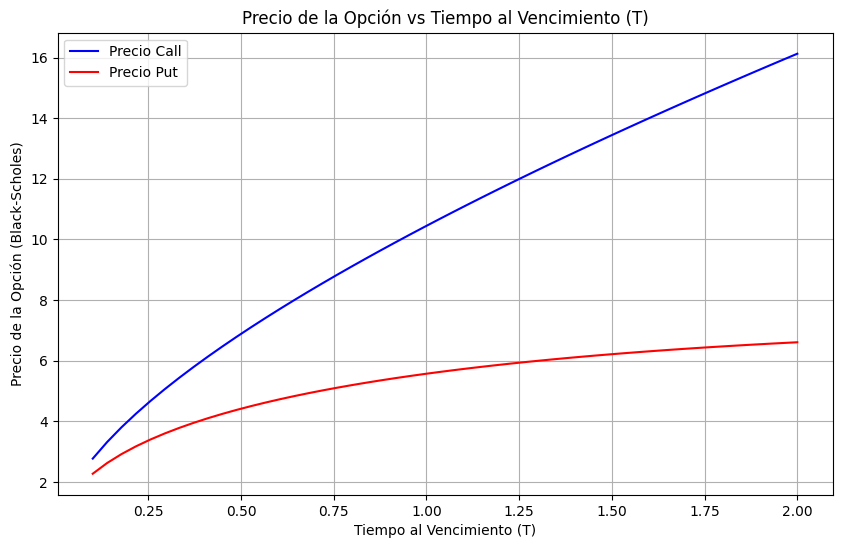

In [29]:
# Parámetros fijos para la sensibilidad de 'T'
S0_plot_t = 100
K_plot_t = 100
r_plot_t = 0.05
vol_plot_t = 0.20

# Tiempos al vencimiento a probar (rango más fino para la gráfica)
times_range = np.linspace(0.1, 2.0, 50) # De 0.1 a 2 años

call_prices_t = [black_scholes(S0_plot_t, K_plot_t, t, r_plot_t, vol_plot_t, option_type='call') for t in times_range]
put_prices_t = [black_scholes(S0_plot_t, K_plot_t, t, r_plot_t, vol_plot_t, option_type='put') for t in times_range]

plt.figure(figsize=(10, 6))
plt.plot(times_range, call_prices_t, label='Precio Call', color='blue')
plt.plot(times_range, put_prices_t, label='Precio Put', color='red')
plt.xlabel('Tiempo al Vencimiento (T)')
plt.ylabel('Precio de la Opción (Black-Scholes)')
plt.title('Precio de la Opción vs Tiempo al Vencimiento (T)')
plt.grid(True)
plt.legend()
plt.show()

### Gráfica de Precio de la Opción vs Tasa de Interés (r)

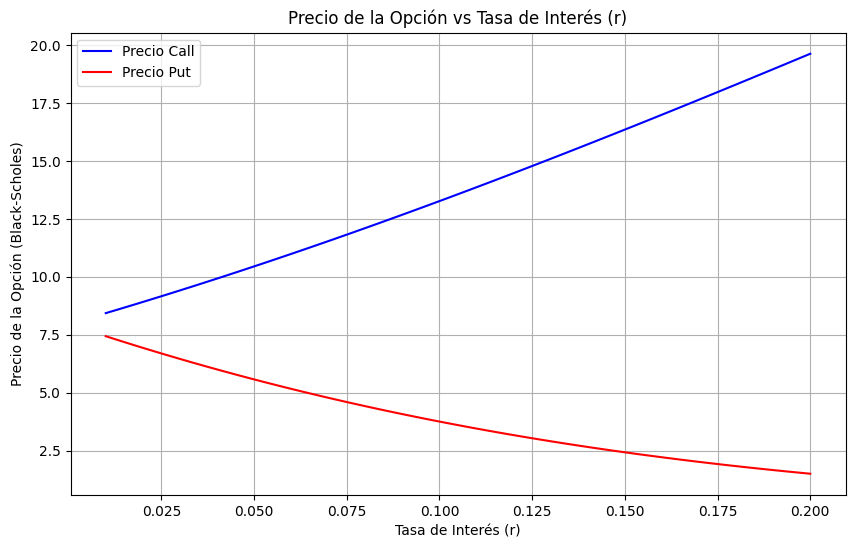

In [30]:
# Parámetros fijos para la sensibilidad de 'r'
S0_plot_r = 100
K_plot_r = 100
T_plot_r = 1
vol_plot_r = 0.20

# Tasas de interés a probar (rango más fino para la gráfica)
rates_range = np.linspace(0.01, 0.20, 50) # De 1% a 20%

call_prices_r = [black_scholes(S0_plot_r, K_plot_r, T_plot_r, r, vol_plot_r, option_type='call') for r in rates_range]
put_prices_r = [black_scholes(S0_plot_r, K_plot_r, T_plot_r, r, vol_plot_r, option_type='put') for r in rates_range]

plt.figure(figsize=(10, 6))
plt.plot(rates_range, call_prices_r, label='Precio Call', color='blue')
plt.plot(rates_range, put_prices_r, label='Precio Put', color='red')
plt.xlabel('Tasa de Interés (r)')
plt.ylabel('Precio de la Opción (Black-Scholes)')
plt.title('Precio de la Opción vs Tasa de Interés (r)')
plt.grid(True)
plt.legend()
plt.show()

## Parte 4: Interpretación



### Precio del Activo Subyacente (S0)

*   **¿Por qué una call aumenta cuando aumenta el precio de la acción?**
    *   Una opción call le da al "dueño" el derecho (pero no la obligación) de comprar el activo subyacente a un precio fijo (precio de ejercicio K). Si el precio del activo subyacente (S) aumenta, la diferencia `S - K` (valor intrínseco de la call) se vuelve más grande y mejor para el comprador.

*   **¿Por qué una put se comporta de manera distinta?**
    *   Una opción put le da al titular el derecho de vender el activo subyacente a un precio fijo (K). Si el precio del activo subyacente (S) aumenta, la diferencia `K - S` (valor intrínseco de la put) disminuye o se hace cero/negativa. Esto hace que baje su valor.

### Volatilidad (sigma)

*   **¿Por qué una mayor incertidumbre aumenta o disminuye el valor de la opción?**
    *   Una mayor volatilidad aumenta el valor de ambas opciones (call y put). Esto se debe a que una mayor volatilidad significa una mayor probabilidad de movimientos extremos en el precio del activo subyacente. Para el comprador de una opción, esto representa un mayor potencial de ganancia si el precio se mueve favorablemente, mientras que la pérdida se limita a la prima pagada.

### Tiempo al Vencimiento (T)

*   **¿Siempre es deseable tener más tiempo?**
    *   Generalmente, sí, para el comprador de la opción. Más tiempo hasta el vencimiento significa una mayor probabilidad de que el precio del activo subyacente se mueva.

*   **¿Para quién resulta favorable?**
    *   Un mayor tiempo hasta el vencimiento es mejor para el comprador de la opción, ya que tiene más oportunidades para que su posición se vuelva rentable. Pero es peor para el vendedor de la opción, porque está expuesto a la incertidumbre y al riesgo de movimientos durante más tiempo.

### Precio de Ejercicio (K)

*   **¿Cómo modifica el strike la probabilidad de terminar in-the-money?**
    *   Para una opción **call**, un precio de ejercicio (K) *menor* aumenta la probabilidad de terminar 'in-the-money' (o sea, que S > K en el vencimiento).
    *   Para una opción **put**, un precio de ejercicio (K) *mayor* aumenta la probabilidad de terminar 'in-the-money' (o sea, que S < K en el vencimiento).

*   **Definir in-the-money:**
    *   **Opción Call 'in-the-money':** Cuando el precio del activo subyacente (S) es *mayor* que el precio de ejercicio (K) en el momento del vencimiento (S > K).
    *   **Opción Put 'in-the-money':** Cuando el precio del activo subyacente (S) es *menor* que el precio de ejercicio (K) en el momento del vencimiento (S < K).

## Parte 4: Comparación con el Mercado



### Análisis de Parámetros Clave para Inversionistas

*   **Si fueras un inversionista, ¿cuál parámetro consideras más importante monitorear? ¿Por qué? Justifica usando tus resultados.**
    *   Pensaría que el Precio del Activo (S0) y la Volatilidad (sigma) son los parámetros más importantes.
        *   El **Precio del Activo Subyacente (S0)** es importante porque es lo principal del valor de la opción. Un movimiento en S0 tiene un impacto directo e inmediato en la rentabilidad. Los gráficos de sensibilidad nos dejan ver el impacto directo que tiene este S0, dictando si la opción está 'in-the-money' o 'out-of-the-money' .
        *   La **Volatilidad (sigma)** es tmb importante porque nos ayuda a ver la "incertidumbre" futura del activo. Como se ve en los resultados, un aumento en la volatilidad incrementa significativamente el valor de ambas opciones (call y put). Por las mayores oportunidades de ganancias con riesgo limitado.